# Polymer / Additive / Solvent Mixing Calculator

This notebook calculates the required volume of each bottle to make a target casting solution.

Bottles:

1. **Polymer stock**: polymer + solvent  
2. **Polymer-additive stock**: polymer + additive + solvent  
3. **Pure solvent**

All concentrations are **wt% of the total mass of that solution**.

Example:

```text
21 wt% PrimoSpire + 5 wt% PVP in NMP
```

means:

```text
21 wt% PrimoSpire
 5 wt% PVP
74 wt% NMP
```

The notebook also shows the **possible target concentration bounds** based on the stock solutions.

## 1. Set stock solution parameters

Change these values for your actual stock solutions and measured densities.

Density units can be any consistent mass/volume unit, for example `g/mL`. The calculated volumes are in the same volume unit as `target_total_volume_uL`.

In [28]:
# Target final volume
target_total_volume_uL = 1000

# Target final casting dope composition
target_polymer_wt = 17.0      # wt% polymer in final dope
target_additive_wt = 2.0      # wt% additive in final dope

# Bottle 1: normal polymer stock
polymer_stock_polymer_wt = 21.0
polymer_stock_additive_wt = 0.0
polymer_stock_density = 1.10

# Bottle 2: polymer-additive stock
additive_stock_polymer_wt = 17.0
additive_stock_additive_wt = 8.0
additive_stock_density = 1.12

# Bottle 3: pure solvent
solvent_polymer_wt = 0.0
solvent_additive_wt = 0.0
solvent_density = 1.028

round_to_uL = True

## 2. Core calculation functions

The calculation solves three equations:

- polymer mass balance
- additive mass balance
- final volume balance

Unknowns:

```text
Vp = volume of normal polymer stock
Va = volume of polymer-additive stock
Vs = volume of pure solvent
```

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def calculate_mix(
    target_total_volume_uL,
    target_polymer_wt,
    target_additive_wt,
    polymer_stock_polymer_wt,
    additive_stock_polymer_wt,
    additive_stock_additive_wt,
    polymer_stock_density,
    additive_stock_density,
    solvent_density,
    round_to_uL=True,
):
    """Calculate required volumes for polymer stock, polymer-additive stock, and solvent."""

    # Convert wt% to fractions
    Cp_target = target_polymer_wt / 100
    Ca_target = target_additive_wt / 100

    Cp_poly = polymer_stock_polymer_wt / 100
    Cp_add = additive_stock_polymer_wt / 100
    Ca_add = additive_stock_additive_wt / 100

    rho_poly = polymer_stock_density
    rho_add = additive_stock_density
    rho_solvent = solvent_density

    # Unknowns are [Vp, Va, Vs]
    # Vp = normal polymer stock volume
    # Va = polymer-additive stock volume
    # Vs = solvent volume

    A = np.array([
        [(Cp_poly - Cp_target) * rho_poly,
         (Cp_add - Cp_target) * rho_add,
         -Cp_target * rho_solvent],

        [-Ca_target * rho_poly,
         (Ca_add - Ca_target) * rho_add,
         -Ca_target * rho_solvent],

        [1, 1, 1]
    ], dtype=float)

    b = np.array([0, 0, target_total_volume_uL], dtype=float)

    Vp, Va, Vs = np.linalg.solve(A, b)

    if min(Vp, Va, Vs) < -1e-6:
        raise ValueError(
            f"Target is not possible with non-negative volumes. "
            f"Calculated Vp={Vp:.2f}, Va={Va:.2f}, Vs={Vs:.2f} uL"
        )

    # Remove tiny numerical negatives
    Vp = max(Vp, 0)
    Va = max(Va, 0)
    Vs = max(Vs, 0)

    if round_to_uL:
        Vp = round(Vp)
        Va = round(Va)
        Vs = round(target_total_volume_uL - Vp - Va)

    return Vp, Va, Vs


def check_final_composition(
    Vp,
    Va,
    Vs,
    polymer_stock_polymer_wt,
    additive_stock_polymer_wt,
    additive_stock_additive_wt,
    polymer_stock_density,
    additive_stock_density,
    solvent_density,
):
    """Check the actual final wt% from the calculated or rounded volumes."""

    Cp_poly = polymer_stock_polymer_wt / 100
    Cp_add = additive_stock_polymer_wt / 100
    Ca_add = additive_stock_additive_wt / 100

    m_poly_stock = Vp * polymer_stock_density
    m_add_stock = Va * additive_stock_density
    m_solvent = Vs * solvent_density

    total_mass = m_poly_stock + m_add_stock + m_solvent

    polymer_mass = Cp_poly * m_poly_stock + Cp_add * m_add_stock
    additive_mass = Ca_add * m_add_stock
    solvent_mass = total_mass - polymer_mass - additive_mass

    return {
        "final_polymer_wt": 100 * polymer_mass / total_mass,
        "final_additive_wt": 100 * additive_mass / total_mass,
        "final_solvent_wt": 100 * solvent_mass / total_mass,
        "total_mass": total_mass,
    }

## 3. Calculate one target recipe

In [30]:
Vp, Va, Vs = calculate_mix(
    target_total_volume_uL=target_total_volume_uL,
    target_polymer_wt=target_polymer_wt,
    target_additive_wt=target_additive_wt,
    polymer_stock_polymer_wt=polymer_stock_polymer_wt,
    additive_stock_polymer_wt=additive_stock_polymer_wt,
    additive_stock_additive_wt=additive_stock_additive_wt,
    polymer_stock_density=polymer_stock_density,
    additive_stock_density=additive_stock_density,
    solvent_density=solvent_density,
    round_to_uL=round_to_uL,
)

composition = check_final_composition(
    Vp, Va, Vs,
    polymer_stock_polymer_wt=polymer_stock_polymer_wt,
    additive_stock_polymer_wt=additive_stock_polymer_wt,
    additive_stock_additive_wt=additive_stock_additive_wt,
    polymer_stock_density=polymer_stock_density,
    additive_stock_density=additive_stock_density,
    solvent_density=solvent_density,
)

result = pd.DataFrame({
    "Bottle": ["Polymer stock", "Polymer-additive stock", "Pure solvent"],
    "Required volume (uL)": [Vp, Va, Vs],
})

display(result)

print("Final composition check after rounding:")
print(f"Polymer:  {composition['final_polymer_wt']:.4f} wt%")
print(f"Additive: {composition['final_additive_wt']:.4f} wt%")
print(f"Solvent:  {composition['final_solvent_wt']:.4f} wt%")

,Bottle,Required volume (uL)
0,Polymer stock,604
1,Polymer-additive stock,244
2,Pure solvent,152


Final composition check after rounding:
Polymer:  17.0011 wt%
Additive: 1.9985 wt%
Solvent:  81.0004 wt%


## 4. Possible target concentration bounds

The achievable target compositions are inside the triangle formed by the three bottle compositions:

```text
pure solvent
polymer stock
polymer-additive stock
```

Densities affect the required volumes, but the possible **wt% composition bounds** are determined by the stock compositions.

In [31]:
def triangle_vertices():
    """Return the composition points for the three bottles."""

    vertices = pd.DataFrame({
        "Bottle": ["Pure solvent", "Polymer stock", "Polymer-additive stock"],
        "Polymer wt%": [0, polymer_stock_polymer_wt, additive_stock_polymer_wt],
        "Additive wt%": [0, polymer_stock_additive_wt, additive_stock_additive_wt],
    })

    return vertices


vertices = triangle_vertices()
display(vertices)

print("Overall simple bounds:")
print(f"Polymer wt% must be between {vertices['Polymer wt%'].min():.2f} and {vertices['Polymer wt%'].max():.2f}")
print(f"Additive wt% must be between {vertices['Additive wt%'].min():.2f} and {vertices['Additive wt%'].max():.2f}")
print()
print("Important: not every combination inside those simple min/max bounds is possible.")
print("The target point must be inside the triangle shown below.")

,Bottle,Polymer wt%,Additive wt%
0,Pure solvent,0.0,0.0
1,Polymer stock,21.0,0.0
2,Polymer-additive stock,17.0,8.0


Overall simple bounds:
Polymer wt% must be between 0.00 and 21.00
Additive wt% must be between 0.00 and 8.00

Important: not every combination inside those simple min/max bounds is possible.
The target point must be inside the triangle shown below.


In [32]:
def additive_bounds_at_polymer(target_polymer_wt):
    """Return min and max additive wt% possible at a given polymer wt%."""

    pts = vertices[["Polymer wt%", "Additive wt%"]].to_numpy(dtype=float)
    intersections = []

    # Check intersection with each triangle edge
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        x1, y1 = pts[i]
        x2, y2 = pts[j]

        # Vertical edge
        if abs(x2 - x1) < 1e-12:
            if abs(target_polymer_wt - x1) < 1e-12:
                intersections.extend([y1, y2])
            continue

        # Non-vertical edge
        if min(x1, x2) - 1e-12 <= target_polymer_wt <= max(x1, x2) + 1e-12:
            t = (target_polymer_wt - x1) / (x2 - x1)
            y = y1 + t * (y2 - y1)
            intersections.append(y)

    if len(intersections) == 0:
        return None, None

    return min(intersections), max(intersections)


min_add, max_add = additive_bounds_at_polymer(target_polymer_wt)

if min_add is None:
    print(f"At {target_polymer_wt:.2f} wt% polymer, no additive concentration is possible.")
else:
    print(f"At {target_polymer_wt:.2f} wt% polymer:")
    print(f"Possible additive range = {min_add:.3f} to {max_add:.3f} wt%")

At 17.00 wt% polymer:
Possible additive range = 0.000 to 8.000 wt%


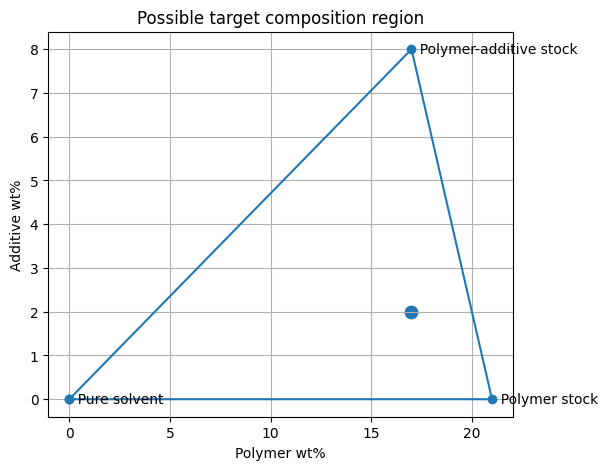

In [33]:
# Plot possible target region
pts = vertices[["Polymer wt%", "Additive wt%"]].to_numpy(dtype=float)

# Close the triangle for plotting
closed_pts = np.vstack([pts, pts[0]])

plt.figure(figsize=(6, 5))
plt.plot(closed_pts[:, 0], closed_pts[:, 1], marker="o")
plt.scatter([target_polymer_wt], [target_additive_wt], s=80)

for _, row in vertices.iterrows():
    plt.text(row["Polymer wt%"], row["Additive wt%"], "  " + row["Bottle"], va="center")

plt.xlabel("Polymer wt%")
plt.ylabel("Additive wt%")
plt.title("Possible target composition region")
plt.grid(True)
plt.show()

## 5. Batch recipe table

Add more rows to calculate multiple target recipes at once.

In [34]:
recipes = pd.DataFrame({
    "target_total_volume_uL": [1000, 1000, 1000, 1000],
    "target_polymer_wt": [15, 17, 19, 21],
    "target_additive_wt": [1, 2, 3, 4],
})

display(recipes)

,target_total_volume_uL,target_polymer_wt,target_additive_wt
0,1000,15,1
1,1000,17,2
2,1000,19,3
3,1000,21,4


In [35]:
batch_results = []

for _, row in recipes.iterrows():
    try:
        Vp, Va, Vs = calculate_mix(
            target_total_volume_uL=row["target_total_volume_uL"],
            target_polymer_wt=row["target_polymer_wt"],
            target_additive_wt=row["target_additive_wt"],
            polymer_stock_polymer_wt=polymer_stock_polymer_wt,
            additive_stock_polymer_wt=additive_stock_polymer_wt,
            additive_stock_additive_wt=additive_stock_additive_wt,
            polymer_stock_density=polymer_stock_density,
            additive_stock_density=additive_stock_density,
            solvent_density=solvent_density,
            round_to_uL=round_to_uL,
        )

        comp = check_final_composition(
            Vp, Va, Vs,
            polymer_stock_polymer_wt=polymer_stock_polymer_wt,
            additive_stock_polymer_wt=additive_stock_polymer_wt,
            additive_stock_additive_wt=additive_stock_additive_wt,
            polymer_stock_density=polymer_stock_density,
            additive_stock_density=additive_stock_density,
            solvent_density=solvent_density,
        )

        batch_results.append({
            "target_total_volume_uL": row["target_total_volume_uL"],
            "target_polymer_wt": row["target_polymer_wt"],
            "target_additive_wt": row["target_additive_wt"],
            "polymer_stock_uL": Vp,
            "polymer_additive_stock_uL": Va,
            "solvent_uL": Vs,
            "final_polymer_wt": comp["final_polymer_wt"],
            "final_additive_wt": comp["final_additive_wt"],
            "status": "OK",
        })

    except Exception as e:
        batch_results.append({
            "target_total_volume_uL": row["target_total_volume_uL"],
            "target_polymer_wt": row["target_polymer_wt"],
            "target_additive_wt": row["target_additive_wt"],
            "polymer_stock_uL": np.nan,
            "polymer_additive_stock_uL": np.nan,
            "solvent_uL": np.nan,
            "final_polymer_wt": np.nan,
            "final_additive_wt": np.nan,
            "status": str(e),
        })

batch_results = pd.DataFrame(batch_results)
display(batch_results)

,target_total_volume_uL,target_polymer_wt,target_additive_wt,polymer_stock_uL,polymer_additive_stock_uL,solvent_uL,final_polymer_wt,final_additive_wt,status
0,1000,15,1,603.0,121.0,276.0,14.995307,1.001489,OK
1,1000,17,2,604.0,244.0,152.0,17.001141,1.998508,OK
2,1000,19,3,604.0,370.0,26.0,18.992916,2.998748,OK
3,1000,21,4,NaN,NaN,NaN,NaN,NaN,Target is not possible with non-negative volum...


## 6. Notes

- The target composition must be inside the triangle shown above.
- If the calculated volume is negative, that target recipe is not possible with the current stock bottles.
- Densities are important for converting volume to mass.
- Rounding to whole microliters slightly changes the final wt%. The notebook reports the final composition after rounding.

## 7. 4th bottle -- no-polymer additive stock (planned, not yet available)

A fourth stock is planned: a **pure additive stock with no polymer** (matches
`polymer_additive_bounds.py`'s `no_polymer_polymer_wt_percent` / `no_polymer_additive_wt_percent`
fields, and its `USE_FOURTH_BOTTLE` toggle). The physical bottle doesn't exist yet -- `USE_FOURTH_BOTTLE`
below defaults to `True` here just to preview what the feasible region looks like once it does;
set it back to `False` to see the notebook plot the original 3-bottle triangle again.

Extending the **achievable composition bounds** to 4 bottles is straightforward (the feasible
region becomes a quadrilateral instead of a triangle).

Extending **`calculate_mix`** to 4 bottles is *not* included here: with 4 bottle volumes as
unknowns but only 3 mass-balance equations (polymer, additive, total volume), the system is
underdetermined -- there are infinitely many volume combinations that hit the same target wt%.
Solving it needs one more rule (e.g. "prefer bottle 4 over bottle 2 when additive is needed
without extra polymer", or a minimum-total-volume objective) that should be decided once the
bottle is actually available, not guessed here.

,Bottle,Polymer wt%,Additive wt%
0,Pure solvent,0.0,0.0
1,Polymer stock,21.0,0.0
2,Polymer-additive stock,17.0,8.0
3,No-polymer additive stock,0.0,8.0


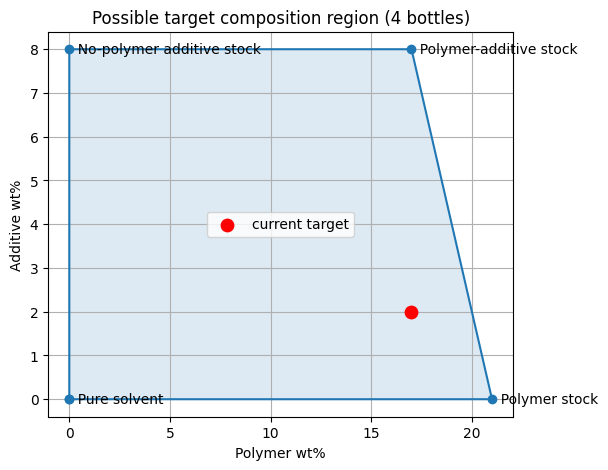

In [36]:
# Set False to go back to the original 3-bottle triangle.
USE_FOURTH_BOTTLE = True

# Bottle 4: no-polymer additive stock (matches polymer_additive_bounds.py's
# StockParameters.no_polymer_polymer_wt_percent / no_polymer_additive_wt_percent)
no_polymer_polymer_wt = 0.0
no_polymer_additive_wt = 8.0
no_polymer_density = 1.12


def region_vertices(use_fourth_bottle=USE_FOURTH_BOTTLE):
    """Return the composition points for the feasible region -- triangle (3 bottles) or
    quadrilateral (4 bottles, once the no-polymer stock exists)."""
    rows = [
        {"Bottle": "Pure solvent", "Polymer wt%": 0, "Additive wt%": 0},
        {"Bottle": "Polymer stock", "Polymer wt%": polymer_stock_polymer_wt, "Additive wt%": polymer_stock_additive_wt},
        {"Bottle": "Polymer-additive stock", "Polymer wt%": additive_stock_polymer_wt, "Additive wt%": additive_stock_additive_wt},
    ]
    if use_fourth_bottle:
        rows.append({"Bottle": "No-polymer additive stock", "Polymer wt%": no_polymer_polymer_wt, "Additive wt%": no_polymer_additive_wt})
    return pd.DataFrame(rows)


region = region_vertices()
display(region)

# Plot the feasible region (quadrilateral if USE_FOURTH_BOTTLE, else the original triangle)
pts = region[["Polymer wt%", "Additive wt%"]].to_numpy(dtype=float)
# order for a non-self-intersecting polygon: solvent -> polymer -> additive -> (no-polymer) -> back to solvent
order = [0, 1, 2, 3, 0] if USE_FOURTH_BOTTLE else [0, 1, 2, 0]
closed_pts = pts[order]

plt.figure(figsize=(6, 5))
plt.plot(closed_pts[:, 0], closed_pts[:, 1], marker="o")
plt.fill(closed_pts[:, 0], closed_pts[:, 1], alpha=0.15)
plt.scatter([target_polymer_wt], [target_additive_wt], s=80, color="red", zorder=5, label="current target")

for _, row in region.iterrows():
    plt.text(row["Polymer wt%"], row["Additive wt%"], "  " + row["Bottle"], va="center")

plt.xlabel("Polymer wt%")
plt.ylabel("Additive wt%")
plt.title(f"Possible target composition region ({'4' if USE_FOURTH_BOTTLE else '3'} bottles)")
plt.legend()
plt.grid(True)
plt.show()

# NOTE: calculate_mix() is NOT extended to 4 bottles here -- see markdown above. With 4
# unknown volumes and only 3 mass-balance equations the system is underdetermined; decide
# the extra rule once the bottle exists, then extend calculate_mix/check_final_composition
# the same way polymer_additive_bounds.py's StockParameters was already extended.